<a href="https://colab.research.google.com/github/OmkarShetty10/cv/blob/main/House_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

house_prices_advanced_regression_techniques_path = kagglehub.competition_download('house-prices-advanced-regression-techniques')

print('Data source import complete.')


# Importing Library

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [ ]:
# Standard Library
import matplotlib.pyplot as plt
import seaborn as sns

#Machine learning Library
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin, clone
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

#Statistical Library
from scipy import stats
from scipy.stats import norm, skew
from scipy.special import boxcox1p

# Data Exploration and Preprocessing

### a. Loading the Data

In [ ]:
# Import the dataset

test = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv")
train = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")

### b. Inital Data Exploration

In [ ]:
# Check the structure and train:

print("Train data shape :", train.shape)
print("--"*40)
print("Test data shape :", test.shape)
print("--"*40)

train.head()

Train data shape : (1460, 81)
--------------------------------------------------------------------------------
Test data shape : (1459, 80)
--------------------------------------------------------------------------------


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Check datatypes and missing values:

train.info()
print("--"*40)
print(train.isnull().sum().sort_values(ascending=False))
print("--"*40)
train.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

In [ ]:
# Statistical summary

train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### c. Target Variable Analysis

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


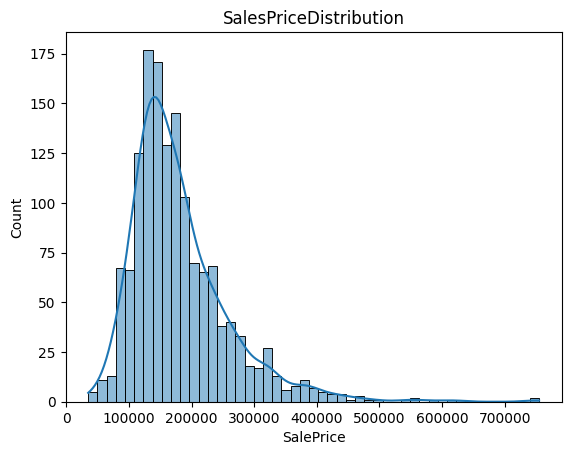

--------------------------------------------------------------------------------


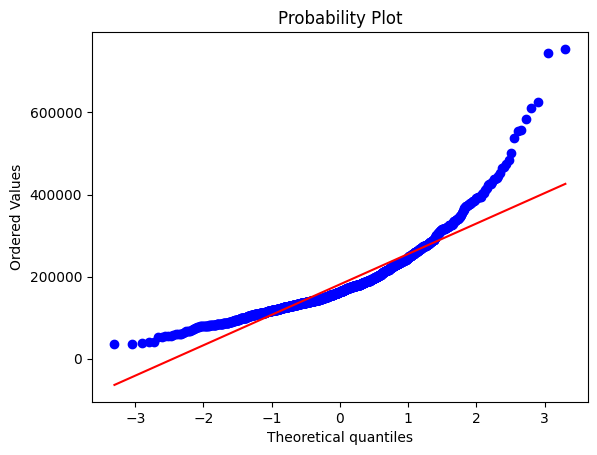

In [ ]:
# Check SalesPrice Distribution

sns.histplot(train['SalePrice'], kde=True)
plt.title('SalesPriceDistribution')
plt.show()

print('--'*40)

stats.probplot(train['SalePrice'], plot=plt)
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


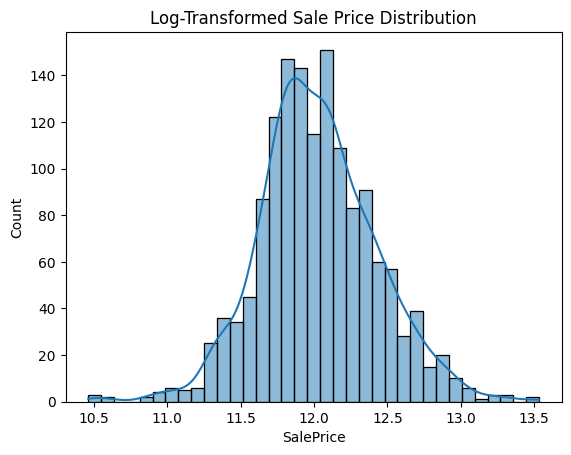

In [ ]:
# Apply Log-Transformation to SalePrice

train['SalePrice'] = np.log1p(train['SalePrice'])
sns.histplot(train['SalePrice'], kde=True)
plt.title('Log-Transformed Sale Price Distribution')
plt.show()

### d. Feature Analysis

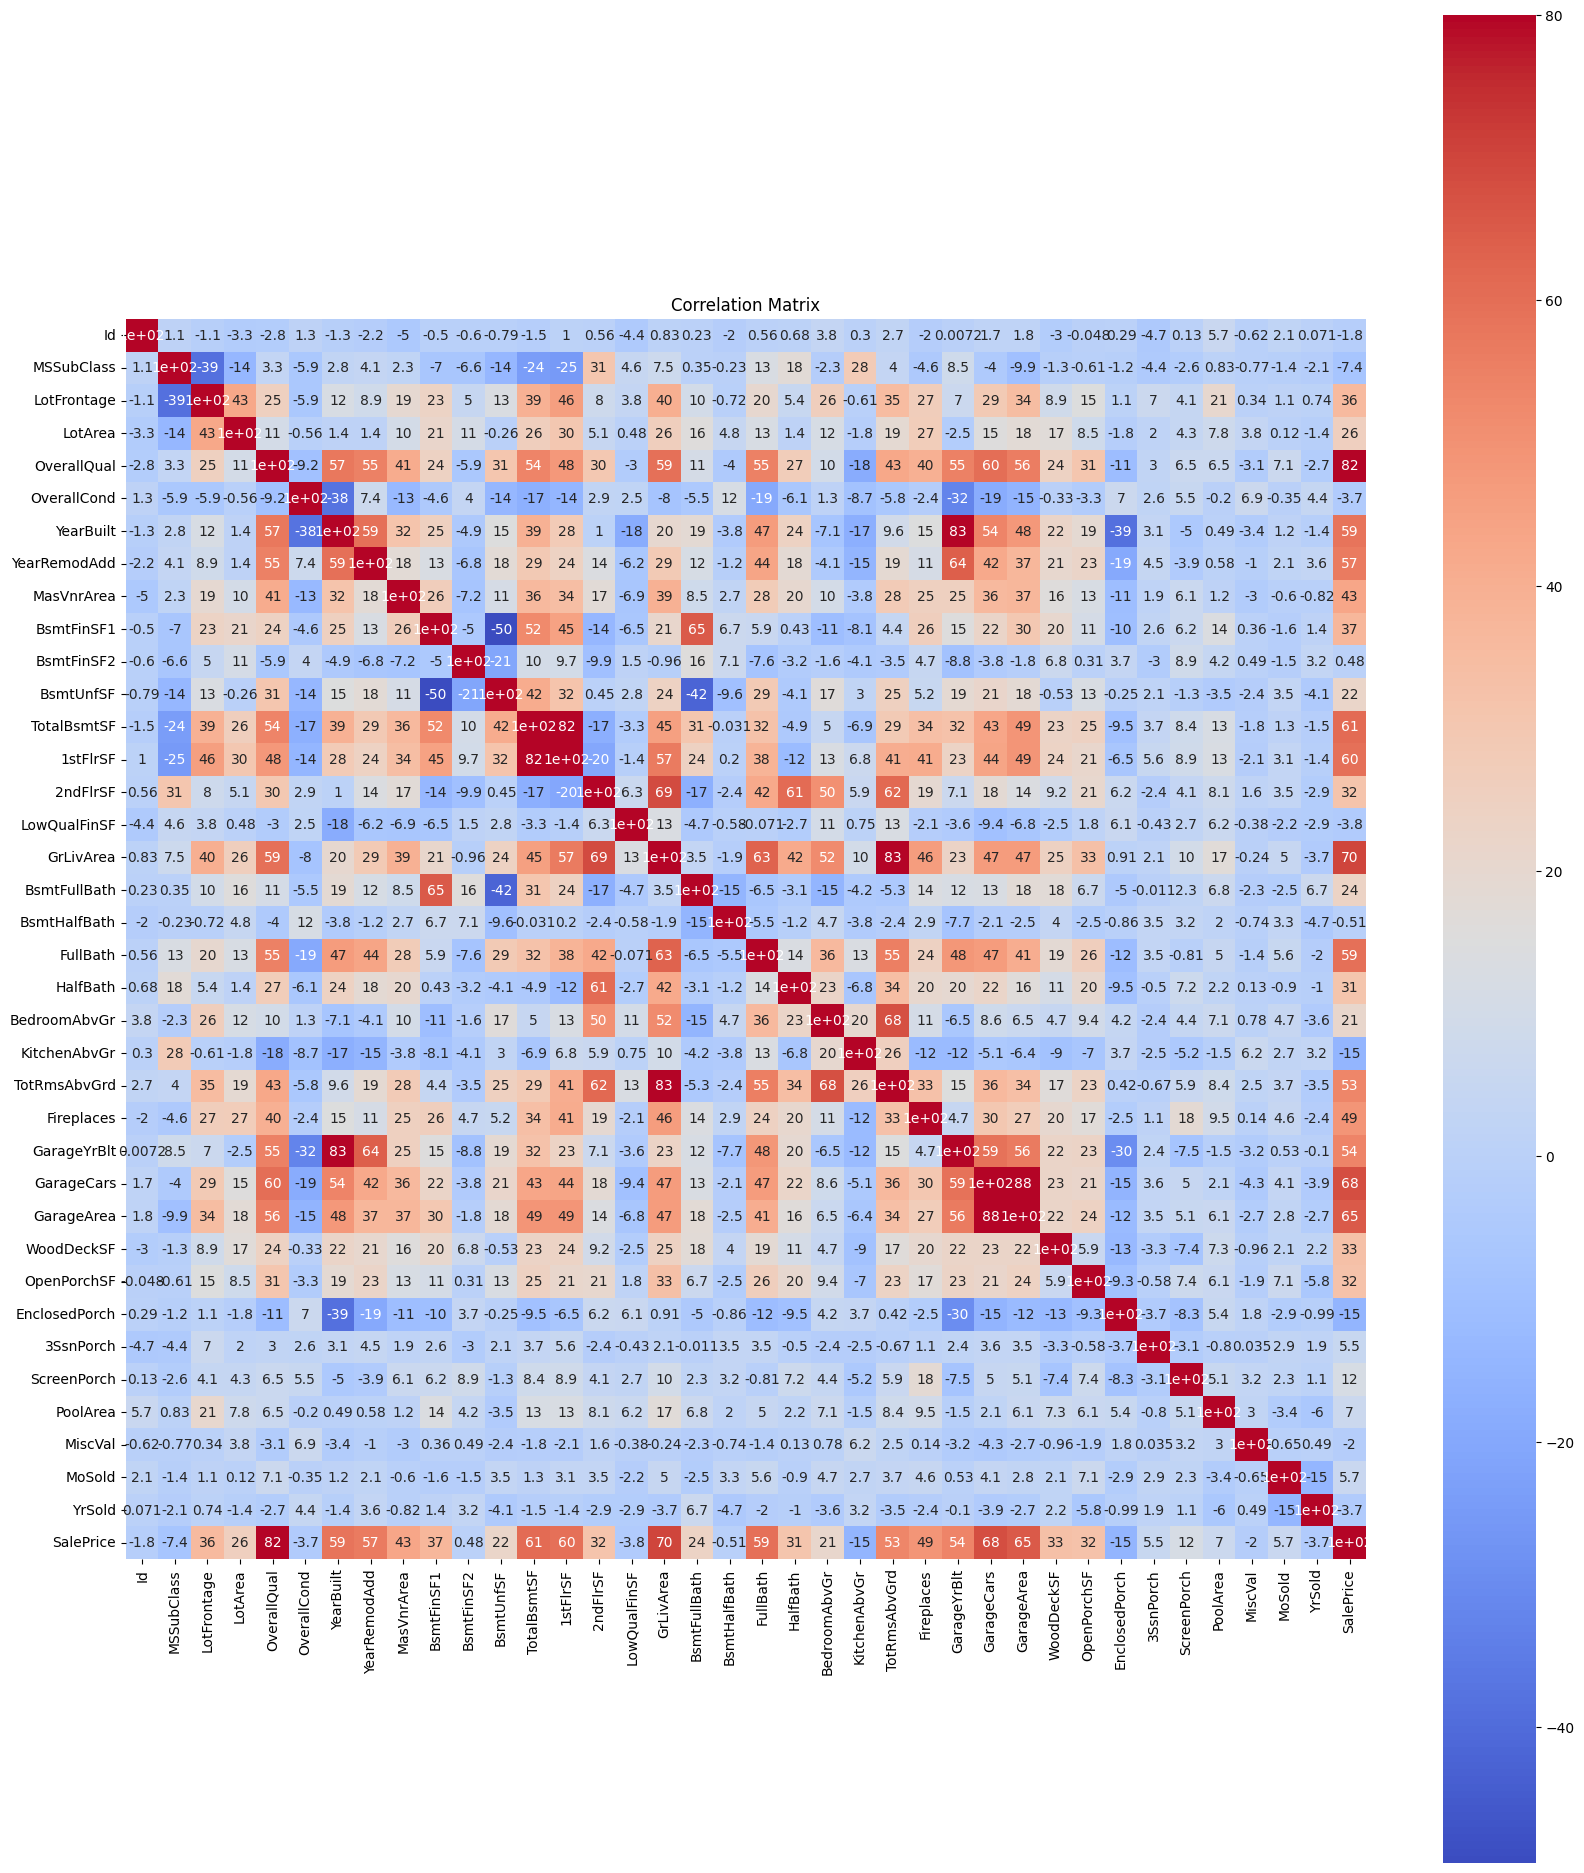

In [ ]:
# Check Correlation between features

corr_matrix = train.select_dtypes(include=['int', 'float']).corr()*100

plt.figure(figsize=(20,24))
sns.heatmap(corr_matrix , vmax=80, square=True, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

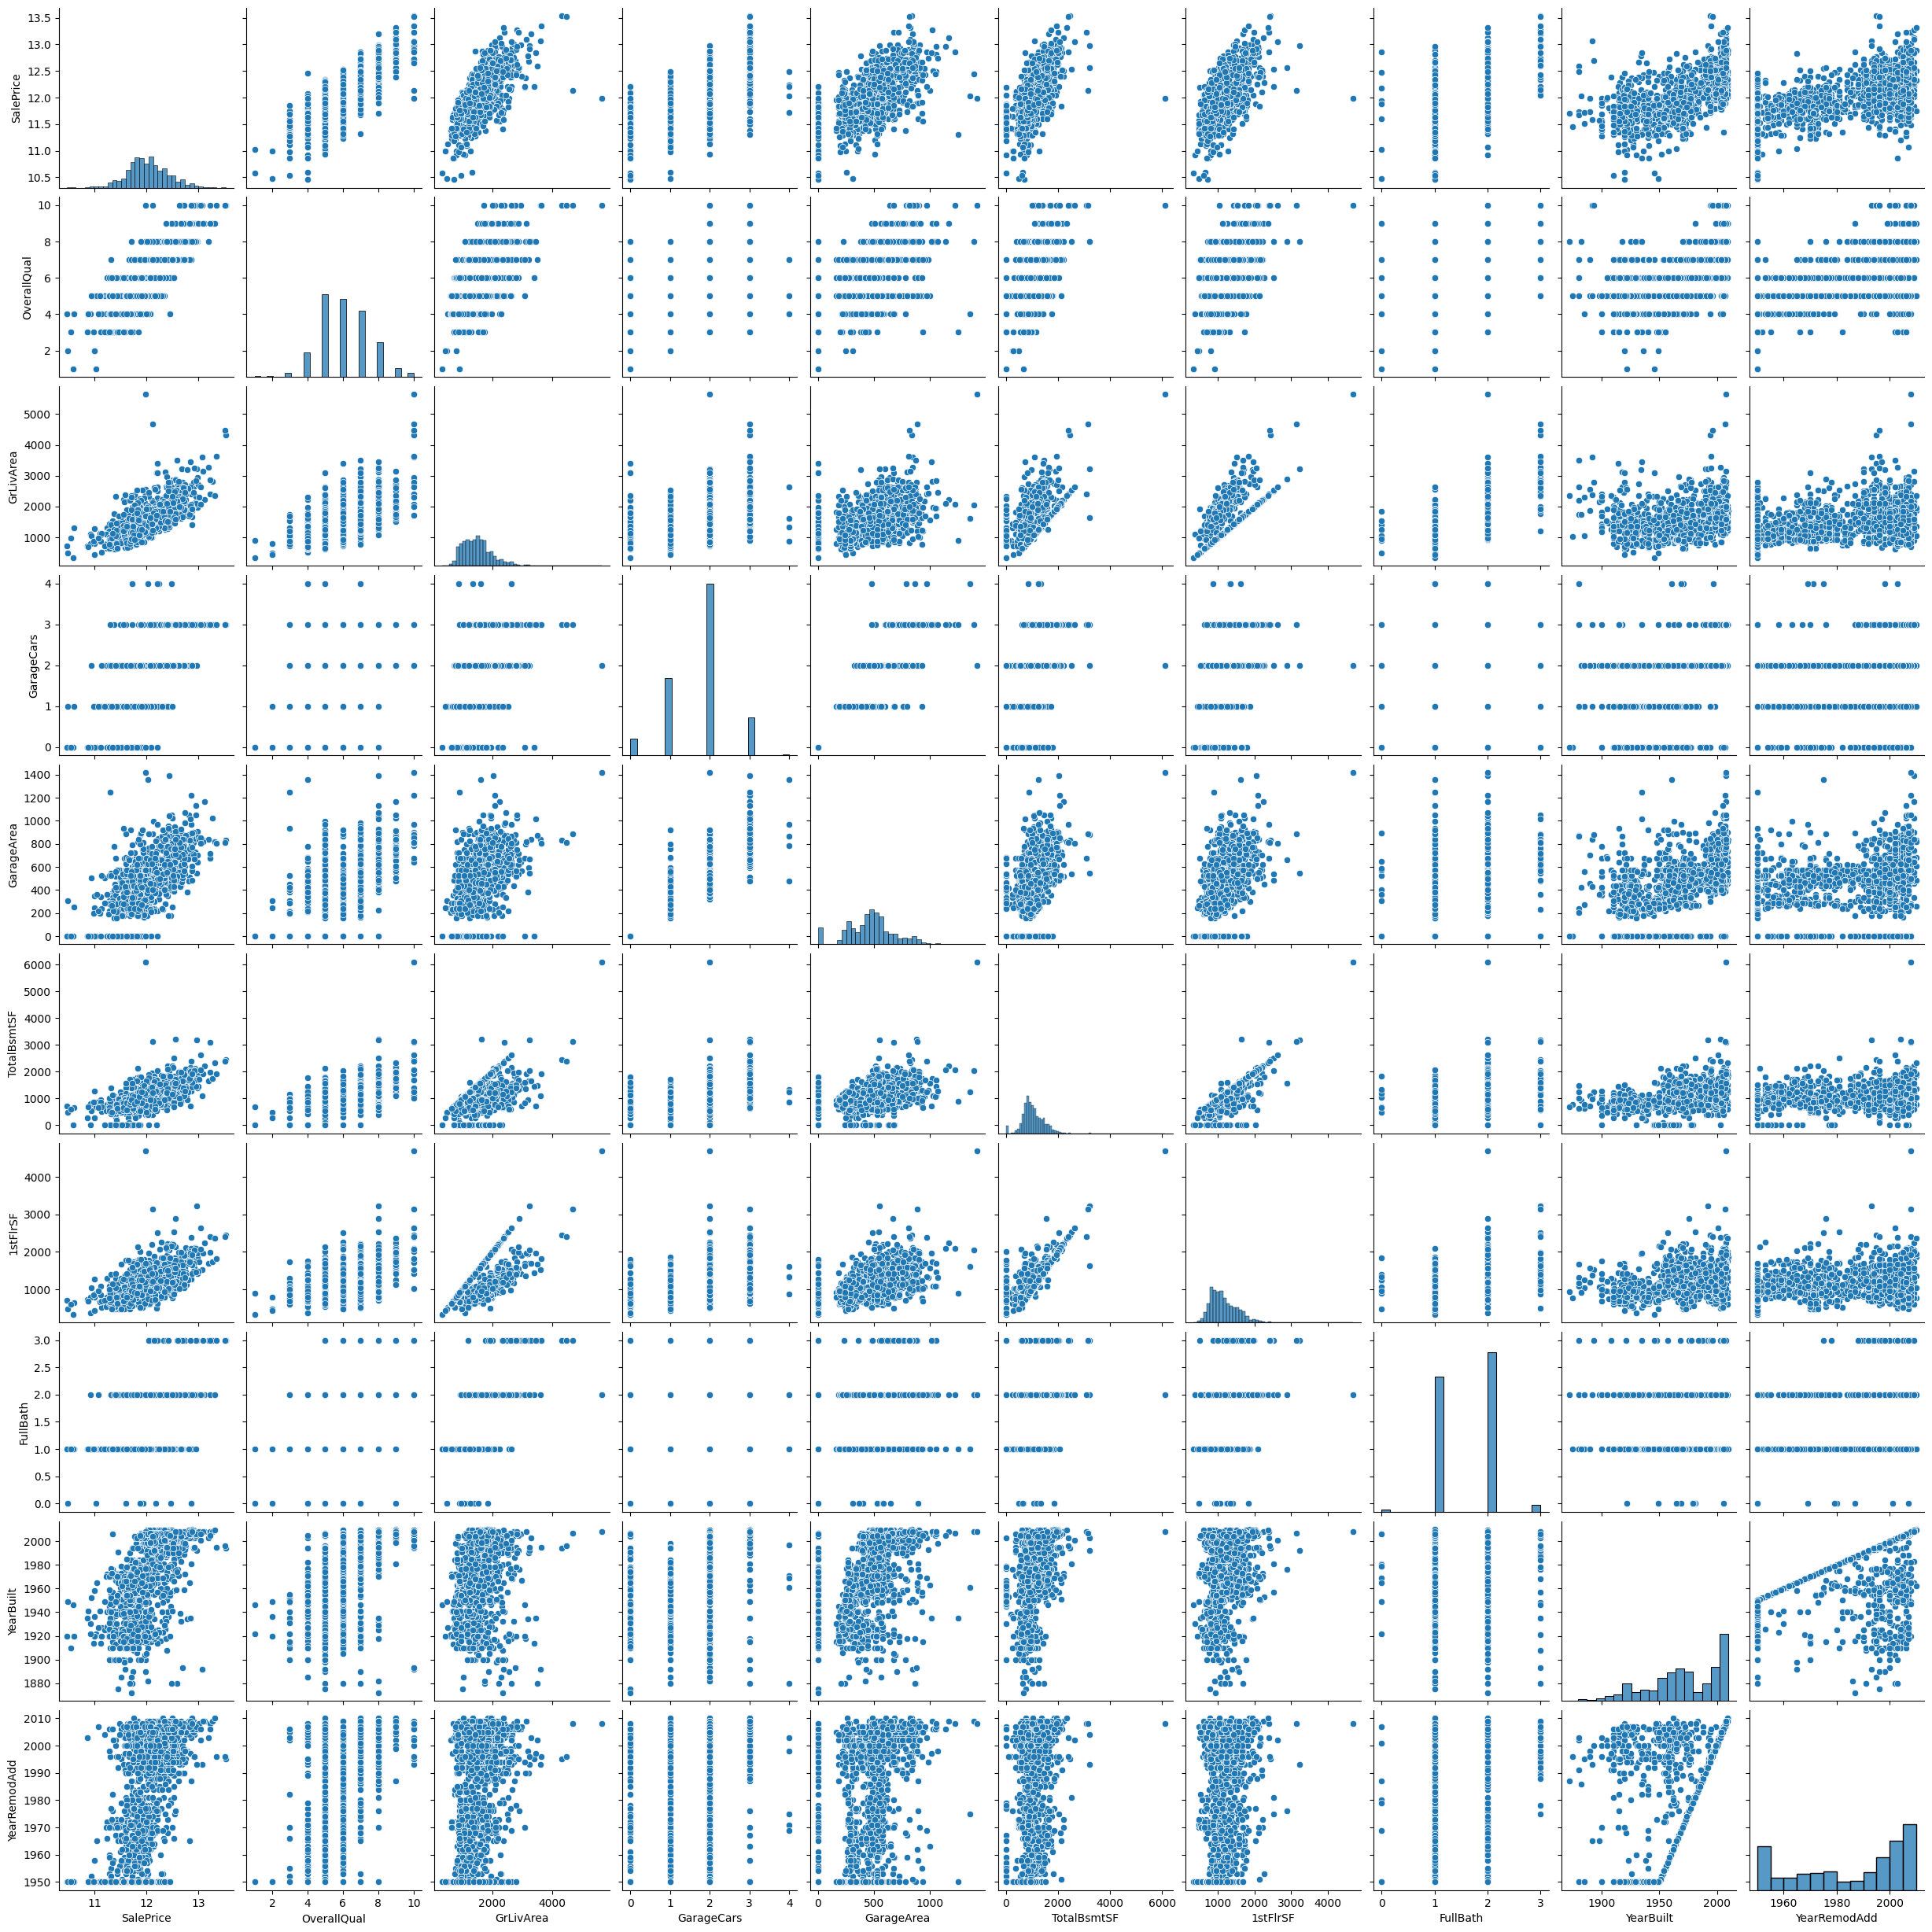

In [ ]:
#Pairplot and top correlated features:

top_corr_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(10).index

sns.pairplot(train[top_corr_features])
plt.show()

### e. Handling missing values

In [ ]:
# Identifying missing values
missing_values=  train.isnull().sum().sort_values(ascending=False)
missing_percent = (train.isnull().sum()/len(train))*100
missing_data = pd.concat([missing_values, missing_percent], axis=1, keys=['Total','Percent'])
missing_data = missing_data[missing_data['Total']>0]
missing_data

,Total,Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageYrBlt,81,5.547945
GarageCond,81,5.547945
GarageType,81,5.547945


In [ ]:
# drop columns with to much null values
cols_to_drop = missing_data[missing_data['Percent']>50].index
train = train.drop(cols_to_drop, axis=1)
test = test.drop(cols_to_drop, axis=1)

In [ ]:
# Imputing missing values
for df in [train, test]:
    for col in df.columns:
        if df[col].dtypes == 'object':
            df[col].fillna('None')
        else :
            df[col].fillna(df[col].median())

train


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,12.247699
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,12.109016
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,12.317171
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,11.849405
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,12.429220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,8,2007,WD,Normal,12.072547
1456,1457,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2010,WD,Normal,12.254868
1457,1458,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,2500,5,2010,WD,Normal,12.493133
1458,1459,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,...,112,0,0,0,0,4,2010,WD,Normal,11.864469


# Feature Engineering

### a. Combining Datasets

In [ ]:
# Save the ID columns
train_id = train['Id']
test_id = test['Id']

# Drop 'Id' columns
train.drop(['Id'], axis=1)
test.drop(['Id'], axis=1)

# Take the shape, concat dataset and drop SalesPrice
ntrain = train.shape[0]
ntest = test.shape[0]
y_train = train['SalePrice'].values
all_data = pd.concat([train, test]).reset_index(drop=True)
all_data.drop(['SalePrice'], axis=1, inplace=True)

all_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,61,0,0,0,0,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,42,0,0,0,0,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,35,272,0,0,0,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,84,0,0,0,0,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,160,RM,21.0,1936,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,0,6,2006,WD,Normal
2915,2916,160,RM,21.0,1894,Pave,Reg,Lvl,AllPub,Inside,...,24,0,0,0,0,0,4,2006,WD,Abnorml
2916,2917,20,RL,160.0,20000,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,0,9,2006,WD,Abnorml
2917,2918,85,RL,62.0,10441,Pave,Reg,Lvl,AllPub,Inside,...,32,0,0,0,0,700,7,2006,WD,Normal


### b. Fixing Skewed Numerical Features

In [ ]:
#Calculate skewness
num_feat = all_data.dtypes[all_data.dtypes != "object"].index
skewed_feat = all_data[num_feat].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewness = pd.DataFrame({'Skew':skewed_feat})
skewness

,Skew
MiscVal,21.947195
PoolArea,16.898328
LotArea,12.822431
LowQualFinSF,12.088761
3SsnPorch,11.376065
KitchenAbvGr,4.302254
BsmtFinSF2,4.145323
EnclosedPorch,4.003891
ScreenPorch,3.946694
BsmtHalfBath,3.929996


In [ ]:
#transform skewed features
skewed_features = skewness[abs(skewness)>0.75].index
lam=0.15

for feat in skewed_features:
    all_data[feat] = boxcox1p(all_data[feat], lam)

all_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,0.730463,5.684507,RL,5.831328,19.212182,Pave,Reg,Lvl,AllPub,Inside,...,5.714669,0.000000,0.0,0.0,0.0,0.000000,1.194318,14.195323,WD,Normal
1,1.194318,3.858807,RL,6.221214,19.712205,Pave,Reg,Lvl,AllPub,FR2,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,2.055642,14.193765,WD,Normal
2,1.540963,5.684507,RL,5.914940,20.347241,Pave,IR1,Lvl,AllPub,Inside,...,5.053371,0.000000,0.0,0.0,0.0,0.000000,2.750250,14.195323,WD,Normal
3,1.820334,5.968981,RL,5.684507,19.691553,Pave,IR1,Lvl,AllPub,Corner,...,4.745132,8.797736,0.0,0.0,0.0,0.000000,1.194318,14.192207,WD,Abnorml
4,2.055642,5.684507,RL,6.314735,21.325160,Pave,IR1,Lvl,AllPub,FR2,...,6.314735,0.000000,0.0,0.0,0.0,0.000000,3.128239,14.195323,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,15.394418,7.620056,RM,3.932510,14.081426,Pave,Reg,Lvl,AllPub,Inside,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,2.259674,14.192207,WD,Normal
2915,15.395553,7.620056,RM,3.932510,14.013314,Pave,Reg,Lvl,AllPub,Inside,...,4.137711,0.000000,0.0,0.0,0.0,0.000000,1.820334,14.192207,WD,Abnorml
2916,15.396687,3.858807,RL,7.620056,22.782058,Pave,Reg,Lvl,AllPub,Inside,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,2.750250,14.192207,WD,Abnorml
2917,15.397821,6.337529,RL,5.744420,20.046557,Pave,Reg,Lvl,AllPub,Inside,...,4.597157,0.000000,0.0,0.0,0.0,11.147538,2.440268,14.192207,WD,Normal


In [ ]:
all_data['PoolArea']

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
2914    0.0
2915    0.0
2916    0.0
2917    0.0
2918    0.0
Name: PoolArea, Length: 2919, dtype: float64

### c. Encoding Categorical Features

In [ ]:
# Label encoding for ordinal variables & nominal

cols = ('FireplaceQu', 'BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond',
        'ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual',
        'BsmtFinType1', 'BsmtFinType2', 'Functional', 'BsmtExposure',
        'GarageFinish', 'LandSlope', 'LotShape', 'PavedDrive', 'Street',
        'CentralAir', 'MSSubClass', 'OverallCond', 'YrSold', 'MoSold')

for c in cols:
    lbl = LabelEncoder()
    lbl.fit(list(all_data[c].values))
    all_data[c] = lbl.transform(list(all_data[c].values))


all_data = pd.get_dummies(all_data)
all_data

,Id,MSSubClass,LotFrontage,LotArea,Street,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.730463,5,5.831328,19.212182,1,3,0,2.440268,4,14.187527,...,False,False,False,True,False,False,False,False,True,False
1,1.194318,0,6.221214,19.712205,1,3,0,2.259674,7,14.145138,...,False,False,False,True,False,False,False,False,True,False
2,1.540963,5,5.914940,20.347241,1,0,0,2.440268,4,14.184404,...,False,False,False,True,False,False,False,False,True,False
3,1.820334,6,5.684507,19.691553,1,0,0,2.440268,4,14.047529,...,False,False,False,True,True,False,False,False,False,False
4,2.055642,5,6.314735,21.325160,1,0,0,2.602594,4,14.182841,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,15.394418,13,3.932510,14.081426,1,3,0,1.820334,6,14.135652,...,False,False,False,True,False,False,False,False,True,False
2915,15.395553,13,3.932510,14.013314,1,3,0,1.820334,4,14.135652,...,False,False,False,True,True,False,False,False,False,False
2916,15.396687,0,7.620056,22.782058,1,3,0,2.055642,6,14.119786,...,False,False,False,True,True,False,False,False,False,False
2917,15.397821,9,5.744420,20.046557,1,3,0,2.055642,4,14.170316,...,False,False,False,True,False,False,False,False,True,False


### d. Creating New Features

In [ ]:
# New features

all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalBath'] = all_data['FullBath'] + (0.5 * all_data['HalfBath']) + all_data['BsmtFullBath'] + (0.5 * all_data['BsmtHalfBath'])
all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']
all_data['MsSubClass'] = all_data['MSSubClass'].apply(str)

all_data

,Id,MSSubClass,LotFrontage,LotArea,Street,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,...,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,TotalSF,TotalBath,HouseAge,MsSubClass
0,0.730463,5,5.831328,19.212182,1,3,0,2.440268,4,14.187527,...,False,False,False,False,True,False,35.071435,2.290012,-12.187527,5
1,1.194318,0,6.221214,19.712205,1,3,0,2.259674,7,14.145138,...,False,False,False,False,True,False,25.584552,1.559549,-13.145138,0
2,1.540963,5,5.914940,20.347241,1,0,0,2.440268,4,14.184404,...,False,False,False,False,True,False,35.508677,2.290012,-12.184404,5
3,1.820334,6,5.684507,19.691553,1,0,0,2.440268,4,14.047529,...,True,False,False,False,False,False,34.721871,1.460926,-14.047529,6
4,2.055642,5,6.314735,21.325160,1,0,0,2.602594,4,14.182841,...,False,False,False,False,True,False,37.292541,2.290012,-12.182841,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,15.394418,13,3.932510,14.081426,1,3,0,1.820334,6,14.135652,...,False,False,False,False,True,False,31.490617,1.095695,-14.135652,13
2915,15.395553,13,3.932510,14.013314,1,3,0,1.820334,4,14.135652,...,True,False,False,False,False,False,31.490617,1.095695,-14.135652,13
2916,15.396687,0,7.620056,22.782058,1,3,0,2.055642,6,14.119786,...,True,False,False,False,False,False,25.406625,1.460926,-14.119786,0
2917,15.397821,9,5.744420,20.046557,1,3,0,2.055642,4,14.170316,...,False,False,False,False,True,False,23.907563,1.095695,-14.170316,9


# 5. Modeling

### a. Splitting the data into Train and Test sets

In [ ]:
#Look again for null values

null_data = all_data.isnull().sum()
null_data = null_data[null_data > 0].sort_values(ascending=False)


if not null_data.empty :
    print("Columns with null values: ")
    print(null_data)
    print("\nData types of columns: ")
    print(all_data[null_data.index].dtypes)
else:
    print("No missing values!")

Columns with null values: 
LotFrontage     486
GarageYrBlt     159
MasVnrArea       23
BsmtFullBath      2
BsmtHalfBath      2
TotalBath         2
BsmtFinSF1        1
BsmtFinSF2        1
BsmtUnfSF         1
TotalBsmtSF       1
GarageCars        1
GarageArea        1
TotalSF           1
dtype: int64

Data types of columns: 
LotFrontage     float64
GarageYrBlt     float64
MasVnrArea      float64
BsmtFullBath    float64
BsmtHalfBath    float64
TotalBath       float64
BsmtFinSF1      float64
BsmtFinSF2      float64
BsmtUnfSF       float64
TotalBsmtSF     float64
GarageCars      float64
GarageArea      float64
TotalSF         float64
dtype: object


In [ ]:
# FillNa with the median

all_data[null_data.index] = all_data[null_data.index].fillna(all_data[null_data.index].median())
all_data

,Id,MSSubClass,LotFrontage,LotArea,Street,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,...,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,TotalSF,TotalBath,HouseAge,MsSubClass
0,0.730463,5,5.831328,19.212182,1,3,0,2.440268,4,14.187527,...,False,False,False,False,True,False,35.071435,2.290012,-12.187527,5
1,1.194318,0,6.221214,19.712205,1,3,0,2.259674,7,14.145138,...,False,False,False,False,True,False,25.584552,1.559549,-13.145138,0
2,1.540963,5,5.914940,20.347241,1,0,0,2.440268,4,14.184404,...,False,False,False,False,True,False,35.508677,2.290012,-12.184404,5
3,1.820334,6,5.684507,19.691553,1,0,0,2.440268,4,14.047529,...,True,False,False,False,False,False,34.721871,1.460926,-14.047529,6
4,2.055642,5,6.314735,21.325160,1,0,0,2.602594,4,14.182841,...,False,False,False,False,True,False,37.292541,2.290012,-12.182841,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,15.394418,13,3.932510,14.081426,1,3,0,1.820334,6,14.135652,...,False,False,False,False,True,False,31.490617,1.095695,-14.135652,13
2915,15.395553,13,3.932510,14.013314,1,3,0,1.820334,4,14.135652,...,True,False,False,False,False,False,31.490617,1.095695,-14.135652,13
2916,15.396687,0,7.620056,22.782058,1,3,0,2.055642,6,14.119786,...,True,False,False,False,False,False,25.406625,1.460926,-14.119786,0
2917,15.397821,9,5.744420,20.046557,1,3,0,2.055642,4,14.170316,...,False,False,False,False,True,False,23.907563,1.095695,-14.170316,9


In [ ]:
# Get dataset back
train = all_data[:ntrain]
test = all_data[ntrain:]

### b. Evaluation Metric

In [ ]:
# Function Root mean square error
def rmsle(y, y_pred):
    return np.sqrt(mean_square_error(y, y_pred))

### c. Cross-Validation Strategy

In [ ]:
# KFold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

### d. Base Model

In [ ]:
# Lasso Regression
lasso = Lasso(alpha=0.0005, random_state=1)

# Cross Validation
score = np.sqrt(-cross_val_score(lasso, train.values, y_train, scoring="neg_mean_squared_error", cv=kf))
print("Lasso score: {:.4f} ({:.4f})".format(score.mean(), score.std()))

Lasso score: 0.1293 (0.0212)


In [ ]:
# ElasticNet Regression
ENet = ElasticNet(alpha=0.0005, l1_ratio=0.9, random_state=3)

# Cross Validation
score1 = np.sqrt(-cross_val_score(ENet, train.values, y_train, scoring="neg_mean_squared_error", cv=kf))
print("Lasso score: {:.4f} ({:.4f})".format(score1.mean(), score1.std()))

Lasso score: 0.1291 (0.0211)


In [ ]:
# Gradient Boosting Regressor
GBoost = GradientBoostingRegressor(n_estimators=3000,
                                   learning_rate=0.05,
                                   max_depth=4,
                                   max_features='sqrt',
                                   min_samples_leaf=15,
                                   min_samples_split=10,
                                   loss='huber',
                                   random_state=5)

# Cross Validation
score2 = np.sqrt(-cross_val_score(GBoost,train.values,y_train,scoring='neg_mean_squared_error',cv=kf))
print("Gradient Boosting score: {:.4f} ({:.4f}))".format(score2.mean(), score2.std()))

Gradient Boosting score: 0.1248 (0.0180))


In [ ]:
# XGB regressor
model_xgb = xgb.XGBRegressor(colsample_bytree=0.4603,
                             gamma=0.0468,
                             learning_rate=0.05,
                             max_depth=3,
                             min_child_weight=1.7817,
                             n_estimators=2200,
                             reg_alpha=0.4640,
                             reg_lambda=0.8571,
                             subsample=0.5213,
                             verbosity=1,
                             random_state=7,
                             nthread=-1)

# Cross Validation
score = np.sqrt(-cross_val_score(model_xgb, train.values, y_train, scoring="neg_mean_squared_error", cv=kf))
print("XGBoost score: {:.4f} ({:.4f})".format(score.mean(), score.std()))

XGBoost score: 0.1264 (0.0182)


In [ ]:
# LightGBM
model_lgb = lgb.LGBMRegressor(objective='regression',
                              num_leaves=5,
                              learning_rate=0.05,
                              n_estimators=720,
                              max_bin=55,
                              bagging_fraction=0.8,
                              bagging_freq=5,
                              feature_fraction=0.2319,
                              min_data_in_leaf=6,
                              random_state=7,
                              force_row_wise=True)
# Cross Validation
score = np.sqrt(-cross_val_score(model_lgb , train.values, y_train, scoring="neg_mean_squared_error", cv=kf))
print("LightGBM score: {:.4f} ({:.4f}".format(score.mean(), score.std()))

[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Total Bins 1565
[LightGBM] [Info

# 6. Model Evaluation and Selection

### a. Averaging Models

In [ ]:
# Creating Averaging Class:

class AveragingModels(BaseEstimator, RegressorMixin, TransformerMixin):
    def __init__(self, models):
        self.models = models
    def fit(self, X, y):
        self.models_ = [clone(x) for x in self.models]
        for model in self.models_:
            model.fit(X, y)
        return self
    def predict(self, X):
        predictions = np.column_stack([
            model.predict(X) for model in self.models_
        ])
        return np.mean(predictions, axis=1)

# Models to Average:
averaged_models = AveragingModels(models=(ENet, GBoost, model_xgb, model_lgb))

# Cross-Validation Score:
score = np.sqrt(-cross_val_score(averaged_models, train.values, y_train, scoring="neg_mean_squared_error", cv=kf))
print("Averaged base models score: {:.4f} ({:.4f})".format(score.mean(), score.std()))

[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Total Bins 1565
[LightGBM] [Info

### b. Stacking Models

In [ ]:
# Defining Stack Class:

class StackingAveragedModels(BaseEstimator, RegressorMixin, TransformerMixin):
    def __init__(self, base_models, meta_model, n_folds=5):
        self.base_models = base_models
        self.meta_model = meta_model
        self.n_folds = n_folds
    def fit(self, X, y):
        self.base_models_ = [list() for x in self.base_models]
        self.meta_model_ = clone(self.meta_model)
        kf = KFold(n_splits=self.n_folds, shuffle=True, random_state=42)
        out_of_fold_predictions = np.zeros((X.shape[0], len(self.base_models)))
        for i, model in enumerate(self.base_models):
            for train_idx, holdout_idx in kf.split(X, y):
                instance = clone(model)
                instance.fit(X[train_idx], y[train_idx])
                self.base_models_[i].append(instance)
                y_pred = instance.predict(X[holdout_idx])
                out_of_fold_predictions[holdout_idx, i] = y_pred
        self.meta_model_.fit(out_of_fold_predictions, y)
        return self
    def predict(self, X):
        meta_features = np.column_stack([
            np.column_stack([model.predict(X) for model in base_models]).mean(axis=1)
            for base_models in self.base_models_ ])
        return self.meta_model_.predict(meta_features)


# Base Model and Meta Model:

stacked_averaged_models = StackingAveragedModels(base_models=(ENet, GBoost, model_xgb),
                                                 meta_model=lasso)


# Cross Validation Score:

score = np.sqrt(-cross_val_score(stacked_averaged_models, train.values, y_train, scoring="neg_mean_squared_error", cv=kf))
print("Stacked Averaged models score: {:.4f} ({:.4f})".format(score.mean(), score.std()))

Stacked Averaged models score: 0.1219 (0.0202)


# 7. Prediction

In [ ]:
#Train final model:
stacked_averaged_models.fit(train.values, y_train)
model_xgb.fit(train.values, y_train)
model_lgb.fit(train.values, y_train)

#Generate Prediction:
stacked_pred = stacked_averaged_models.predict(test.values)
xgb_pred = model_xgb.predict(test.values)
lgb_pred = model_lgb.predict(test.values)

#Ensemble Prediction:
final_pred = (stacked_pred*0.70) + (xgb_pred*0.15) + (lgb_pred*0.15)
final_pred = np.expm1(final_pred)

[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Total Bins 1601
[LightGBM] [Info

In [ ]:
#Submission:
submission = pd.DataFrame({
    'Id': test_id,
    'SalePrice': final_pred
})
submission.to_csv('submission.csv', index=False)
print("Submission file created!")

Submission file created!


In [ ]:
# Create the submission DataFrame
submission = pd.DataFrame({
    'Id': test_id,
    'SalePrice': final_pred
})

# Save the submission to a CSV file in the correct location
submission.to_csv('/kaggle/working/submission.csv', index=False)
print("Submission file created!")

# If you want to download the file, use the output section in Kaggle notebooks:
# The file will appear in the "Output" tab in your notebook environment.


Submission file created!
